In [52]:
from pathlib import Path
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path("/home/atruergod/python/26-1/26-1")
os.chdir(PROJECT_DIR)
PROJECT_DIR

PosixPath('/home/atruergod/python/26-1/26-1')

In [53]:
DATA_CSV = PROJECT_DIR / "survey_GRM.csv"
DATA_PDF = PROJECT_DIR / "survey_GRM.pdf"

def load_data():
    if DATA_CSV.exists():
        df = pd.read_csv(DATA_CSV)
        return df, "csv"
    elif DATA_PDF.exists():
        # PDF는 표 추출이 흔들릴 수 있습니다. 가능하면 CSV를 권장합니다.
        import camelot
        tables = camelot.read_pdf(str(DATA_PDF), pages="all", flavor="stream")
        # 여러 페이지 표를 단순 concat (실제 PDF 구조에 따라 후처리 필요할 수 있음)
        df = pd.concat([t.df for t in tables], ignore_index=True)

        # 1행이 헤더로 들어있을 수 있어 정리 시도
        df.columns = df.iloc[0].tolist()
        df = df.iloc[1:].copy()
        return df, "pdf(camelot)"
    else:
        raise FileNotFoundError("survey_grm.csv 또는 survey_grm.pdf 를 프로젝트 폴더에 두세요.")

df_raw, src = load_data()
print("loaded from:", src)
df_raw.head()

loaded from: csv


,participant,SE_1,SE_2,SE_3,SE_4,SE_5,SE_6,SE_7,SE_8,SE_9,...,IS_15,IS_16,IS_17,IS_18,IS_19,IS_20,IS_21,IS_22,IS_23,IS_24
0,1,4,4,1,4,1,4,4,1,1,...,1,5,5,1,5,1,5,1,5,5
1,2,4,3,4,3,4,3,3,2,4,...,5,5,5,4,2,4,4,5,4,5
2,3,4,3,4,3,3,4,3,2,4,...,5,5,3,4,3,2,4,4,3,3
3,4,3,3,3,3,3,3,3,2,2,...,4,5,5,5,3,5,4,5,5,3
4,5,4,4,4,4,4,4,4,3,4,...,4,5,4,3,3,3,5,3,4,3


In [54]:
df = df_raw.copy()

# 공백/이상문자 제거 (PDF에서 왔을 때 특히)
df.columns = [str(c).strip() for c in df.columns]

# participant 같은 ID열이 있으면 자동으로 제거(있어도 무방)
id_like = [c for c in df.columns if re.match(r"^participant", c, flags=re.I)]
if id_like:
    df = df.drop(columns=id_like)

# 숫자로 변환 (PDF에서 왔으면 문자열일 가능성 높음)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.shape)
df.isna().mean().sort_values(ascending=False).head(10)

(29, 70)


SE_1     0.0
SE_2     0.0
SE_3     0.0
SE_4     0.0
SE_5     0.0
SE_6     0.0
SE_7     0.0
SE_8     0.0
SE_9     0.0
SE_10    0.0
dtype: float64

In [55]:
def item_cols(prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    # SE_1, SE_2 ... 숫자 기준 정렬
    def key(x):
        m = re.search(r"_(\d+)$", x)
        return int(m.group(1)) if m else 10**9
    return sorted(cols, key=key)

SE_cols = item_cols("SE_")
AS_cols = item_cols("AS_")
IS_cols = item_cols("IS_")

len(SE_cols), len(AS_cols), len(IS_cols), SE_cols[:3], AS_cols[:3], IS_cols[:3]

(10,
 36,
 24,
 ['SE_1', 'SE_2', 'SE_3'],
 ['AS_1', 'AS_2', 'AS_3'],
 ['IS_1', 'IS_2', 'IS_3'])

In [56]:
grm_stan = r"""
data {
  int<lower=1> N;                 // persons
  int<lower=1> J;                 // items
  int<lower=2> K;                 // categories (1..K), same for all items in this fit
  array[N, J] int<lower=1, upper=K> y;
}
parameters {
  vector[N] theta;                // latent trait
  vector<lower=0>[J] a;           // discrimination
  array[J] ordered[K-1] c;        // cutpoints (directly estimated for numerical stability)
}
model {
  // identification
  theta ~ std_normal();

  // weakly-informative priors
  a ~ lognormal(0, 0.5);
  for (j in 1:J) c[j] ~ normal(0, 1.5);

  // likelihood: GRM as ordered_logistic with scaled cutpoints
  for (i in 1:N) {
    for (j in 1:J) {
      y[i, j] ~ ordered_logistic(a[j] * theta[i], c[j]);
    }
  }
}
generated quantities {
  array[N, J] int<lower=1, upper=K> y_rep;
  array[N, J] real log_lik;
  array[J] ordered[K-1] b;        // derived category thresholds (on theta scale)

  for (j in 1:J) {
    b[j] = c[j] / a[j];
  }

  for (i in 1:N) {
    for (j in 1:J) {
      log_lik[i, j] = ordered_logistic_lpmf(y[i, j] | a[j] * theta[i], c[j]);
      y_rep[i, j] = ordered_logistic_rng(a[j] * theta[i], c[j]);
    }
  }
}
"""

stan_file = PROJECT_DIR / "grm_unidim.stan"
stan_file.write_text(grm_stan, encoding="utf-8")
stan_file

PosixPath('/home/atruergod/python/26-1/26-1/grm_unidim.stan')

In [57]:
from cmdstanpy import CmdStanModel
import arviz as az

model = CmdStanModel(stan_file=str(stan_file))

def fit_grm(df_items, K, scale_name, seed=123):
    y = df_items.to_numpy().astype(int)
    N, J = y.shape
    data = {"N": N, "J": J, "K": K, "y": y}

    fit = model.sample(
        data=data,
        chains=4,
        parallel_chains=4,
        iter_warmup=1000,
        iter_sampling=1000,
        adapt_delta=0.9,
        max_treedepth=12,
        seed=seed,
        output_dir=str(PROJECT_DIR / "cmdstan_out"),
    )
    idata = az.from_cmdstanpy(
        posterior=fit,
        log_likelihood="log_lik",
        posterior_predictive="y_rep",
    )
    return fit, idata

01:25:35 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/grm_unidim.stan to exe file /home/atruergod/python/26-1/26-1/grm_unidim


01:25:54 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/grm_unidim


01:25:54 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   5%|▌         | 100/2000 [00:01<00:25, 74.60it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:03<00:29, 60.94it/s, (Warmup)]




chain 1:  15%|█▌        | 300/2000 [00:04<00:26, 64.36it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:05<00:22, 71.98it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:06<00:19, 76.99it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:07<00:15, 90.07it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:08<00:12, 104.03it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:08<00:10, 116.50it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:09<00:08, 125.44it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [00:10<00:07, 128.36it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:11<00:07, 114.18it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:13<00:08, 89.24it/s, (Sampling)] 



01:26:17 - cmdstanpy - INFO - CmdStan done processing.
01:26:17 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -11.9375, but should be greater than the previous element, -11.9375 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -10.9724, but should be greater than the previous element, -10.9724 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -92.5559, but should be greater than the previous element, -92.5559 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -15.092, but should be greater than the previous element, -15.092 (in 'grm_unidim.stan', line 24, column 6 to column 56)
Exception: ordered_lo


         Mean   StdDev    R_hat  ESS_bulk
lp__ -318.162  6.49007  1.00161   1387.12


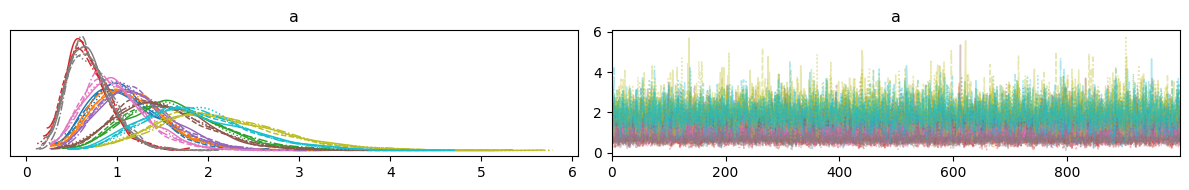

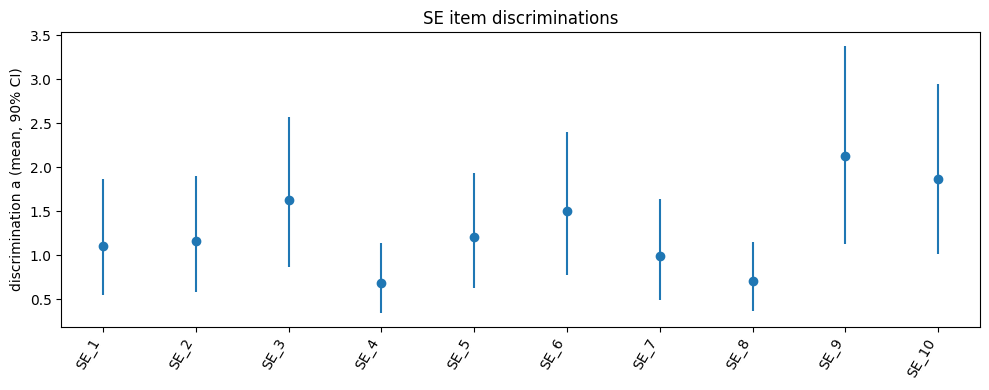

In [58]:
# df_scored를 df로 수정
df_se = df[SE_cols].copy()
fit_se, idata_se = fit_grm(df_se, K=4, scale_name="SE")
print(fit_se.summary().loc[["lp__"], ["Mean","StdDev","R_hat","ESS_bulk"]])

az.summary(idata_se, var_names=["a", "b", "theta"]).head()
az.plot_trace(idata_se, var_names=["a"])
plt.tight_layout()
plt.show()

# 변별도 a_j posterior (요약)
a_se = idata_se.posterior["a"].values  # shape: (chain, draw, J)
a_se_mean = a_se.mean(axis=(0,1))
a_se_ci = np.quantile(a_se.reshape(-1, a_se.shape[-1]), [0.05, 0.95], axis=0)

plt.figure(figsize=(10,4))
x = np.arange(len(SE_cols))
plt.errorbar(x, a_se_mean, yerr=[a_se_mean-a_se_ci[0], a_se_ci[1]-a_se_mean], fmt="o")
plt.xticks(x, SE_cols, rotation=60, ha="right")
plt.ylabel("discrimination a (mean, 90% CI)")
plt.title("SE item discriminations")
plt.tight_layout()
plt.show()

In [59]:
from scipy.special import expit

def grm_category_probs(theta_grid, a, b):
    """
    GRM: P(Y>=k) = logistic(a*(theta - b_k)), k=2..K
    We'll compute P(Y=c) for c=1..K via cumulative differences.
    b: (K-1,) thresholds for k=2..K
    """
    K = len(b) + 1
    # P(Y >= 2..K)
    P_ge = np.zeros((K+1, len(theta_grid)))  # index k
    P_ge[1, :] = 1.0
    for k in range(2, K+1):
        P_ge[k, :] = expit(a * (theta_grid - b[k-2]))
    P_ge[K+1-1, :] = P_ge[K, :]  # just for safety

    # P(Y=c) = P(Y>=c) - P(Y>=c+1)
    P = np.zeros((K, len(theta_grid)))
    for c in range(1, K):
        P[c-1, :] = P_ge[c, :] - P_ge[c+1, :]
    P[K-1, :] = P_ge[K, :]  # last category
    return P  # (K, grid)

def plot_crc(idata, item_names, item_index, K, theta_min=-3, theta_max=3, n_grid=200, n_draws=200):
    theta_grid = np.linspace(theta_min, theta_max, n_grid)
    post = idata.posterior

    a_draws = post["a"].values.reshape(-1, post["a"].shape[-1])[:, item_index]  # (draws,)
    b_draws = post["b"].values.reshape(-1, post["b"].shape[-2], post["b"].shape[-1])[:, item_index, :]  # (draws, K-1)

    # subsample draws for ribbon
    rng = np.random.default_rng(1)
    idx = rng.choice(len(a_draws), size=min(n_draws, len(a_draws)), replace=False)

    P_stack = []
    for t in idx:
        P_stack.append(grm_category_probs(theta_grid, a_draws[t], b_draws[t]))
    P_stack = np.stack(P_stack, axis=0)  # (draws, K, grid)

    P_mean = P_stack.mean(axis=0)
    P_lo = np.quantile(P_stack, 0.05, axis=0)
    P_hi = np.quantile(P_stack, 0.95, axis=0)

    plt.figure(figsize=(8,5))
    for c in range(K):
        plt.plot(theta_grid, P_mean[c], label=f"cat {c+1}")
        plt.fill_between(theta_grid, P_lo[c], P_hi[c], alpha=0.15)

    plt.ylim(0, 1)
    plt.xlabel("theta")
    plt.ylabel("P(response = category)")
    plt.title(f"Category response curves: {item_names[item_index]}")
    plt.legend(ncols=K, fontsize=9)
    plt.tight_layout()
    plt.show()

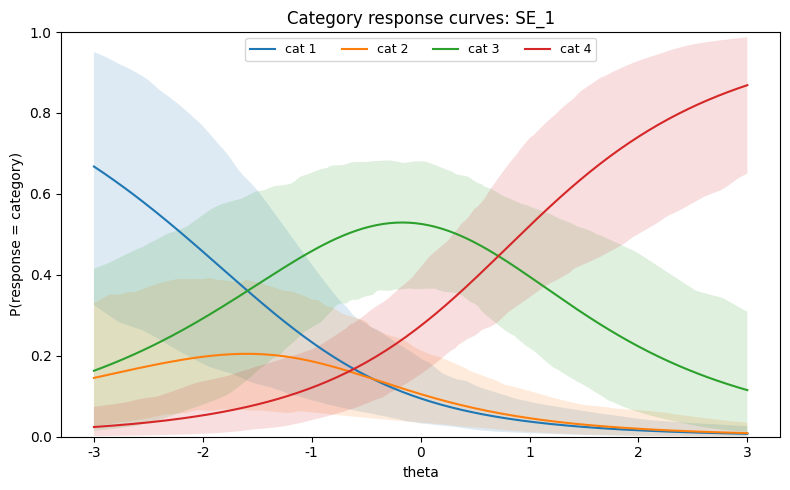

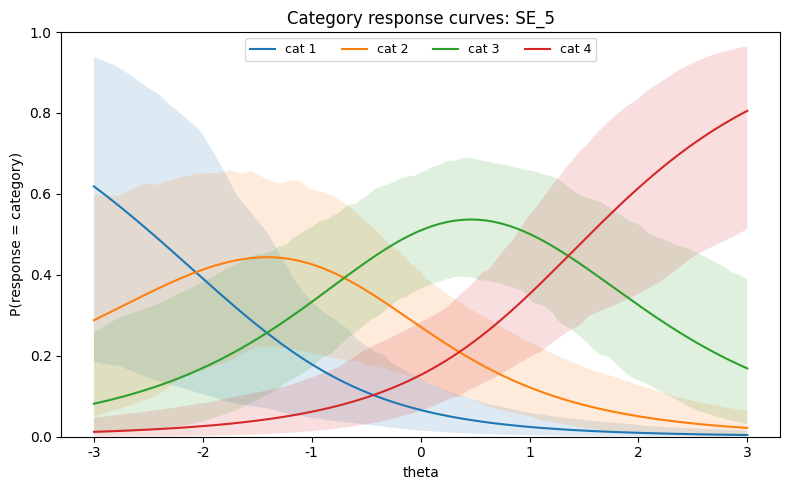

In [60]:
plot_crc(idata_se, SE_cols, item_index=0, K=4)
plot_crc(idata_se, SE_cols, item_index=4, K=4)

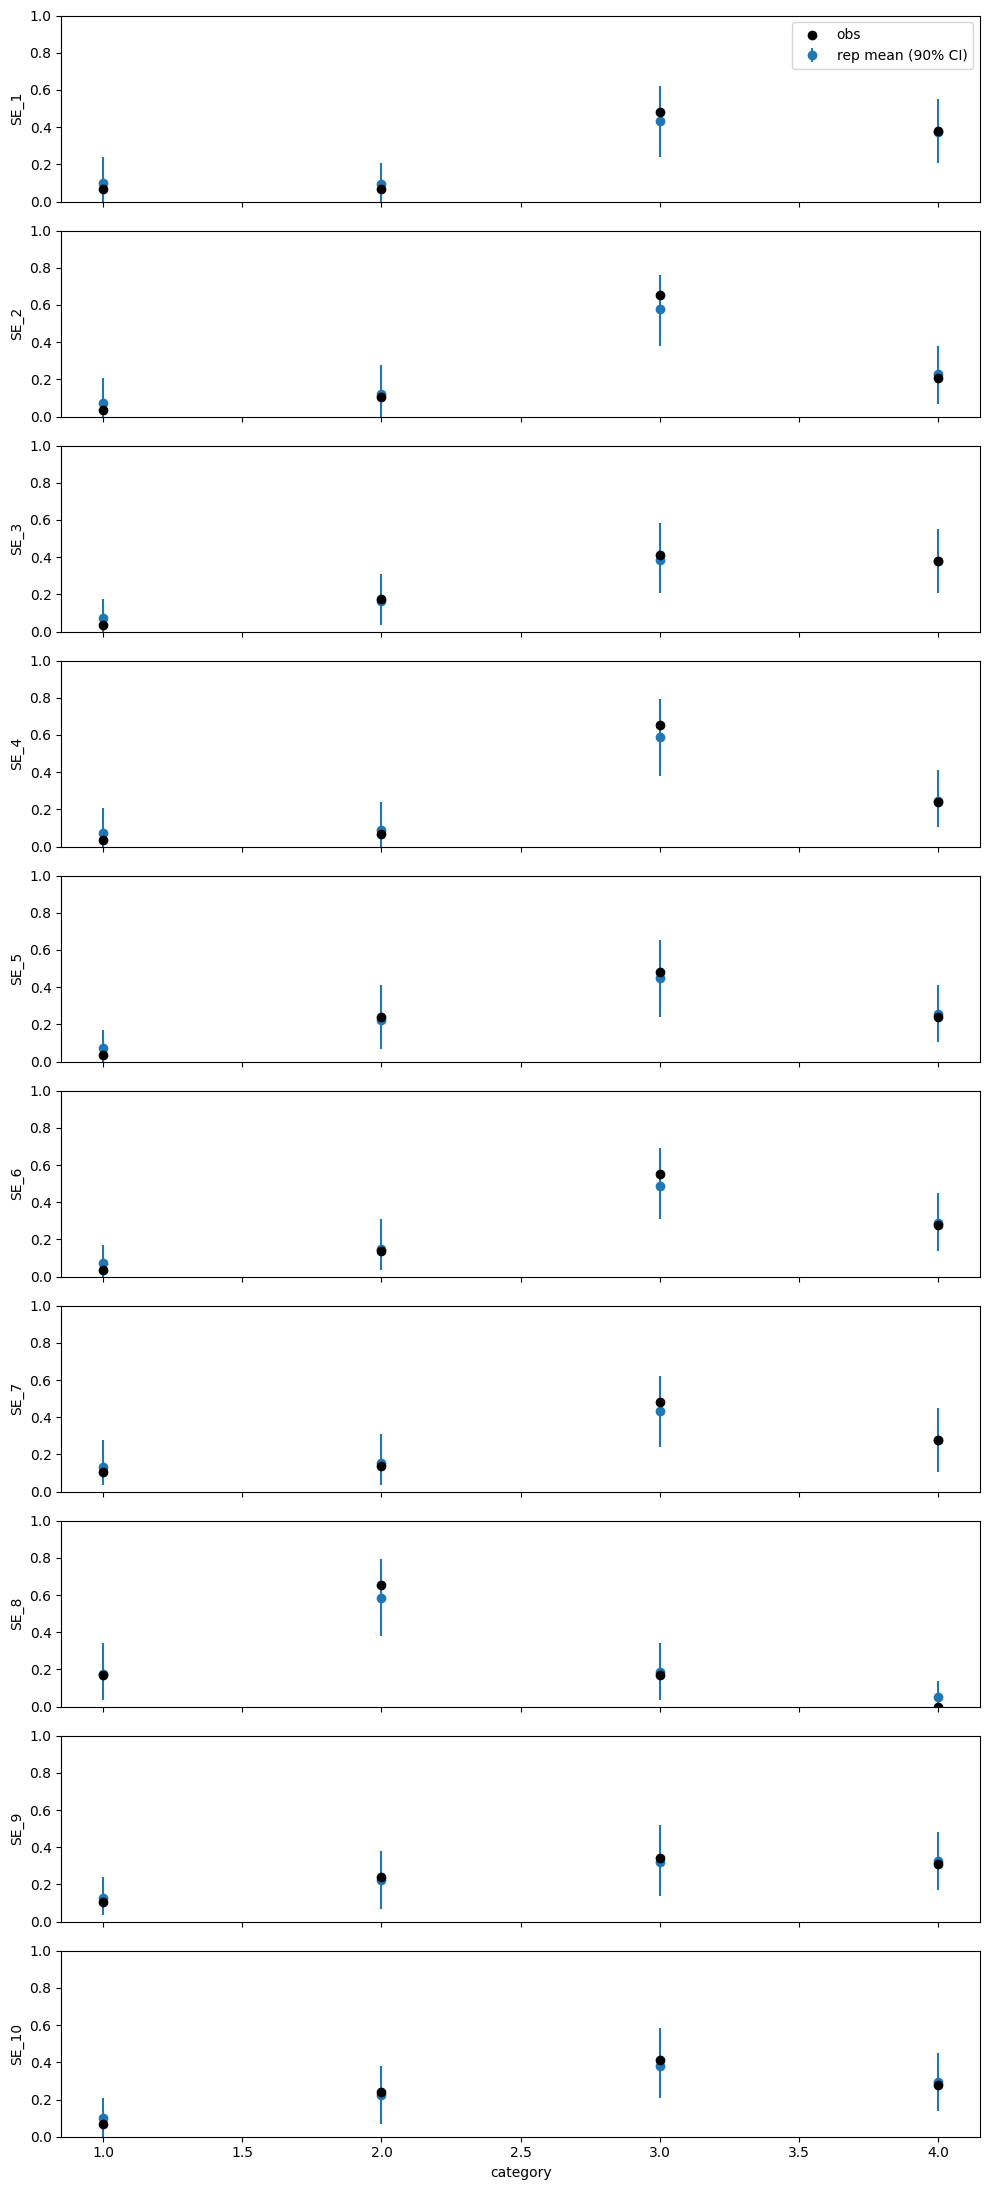

In [61]:
def ppc_category_proportions(idata, df_items, K, max_items=12):
    y_obs = df_items.to_numpy().astype(int)
    y_rep = idata.posterior_predictive["y_rep"].values.astype(int)  # (chain, draw, N, J)
    y_rep = y_rep.reshape(-1, y_rep.shape[-2], y_rep.shape[-1])  # (draws, N, J)

    N, J = y_obs.shape
    Jp = min(J, max_items)

    fig, axes = plt.subplots(Jp, 1, figsize=(10, 2.2*Jp), sharex=True)
    if Jp == 1:
        axes = [axes]

    for j in range(Jp):
        obs_counts = np.bincount(y_obs[:, j], minlength=K+1)[1:]
        obs_prop = obs_counts / obs_counts.sum()

        rep_props = []
        for d in range(y_rep.shape[0]):
            rep_counts = np.bincount(y_rep[d, :, j], minlength=K+1)[1:]
            rep_props.append(rep_counts / rep_counts.sum())
        rep_props = np.stack(rep_props, axis=0)  # (draws, K)

        lo = np.quantile(rep_props, 0.05, axis=0)
        hi = np.quantile(rep_props, 0.95, axis=0)
        mean = rep_props.mean(axis=0)

        x = np.arange(1, K+1)
        ax = axes[j]
        ax.errorbar(x, mean, yerr=[mean-lo, hi-mean], fmt="o", label="rep mean (90% CI)")
        ax.scatter(x, obs_prop, color="black", zorder=3, label="obs")
        ax.set_ylabel(df_items.columns[j])
        ax.set_ylim(0, 1)

    axes[-1].set_xlabel("category")
    axes[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

ppc_category_proportions(idata_se, df_se, K=4, max_items=10)

01:26:29 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:04<01:25, 22.32it/s, (Warmup)]




chain 1:  10%|█         | 200/2000 [00:10<01:33, 19.20it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:14<01:21, 20.76it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:18<01:09, 23.04it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:21<00:59, 25.21it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:24<00:51, 26.95it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:28<00:50, 25.91it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:32<00:45, 26.66it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:36<00:43, 25.41it/s, (Warmup)]






chain 1:  50%|█████     | 1000/2000 [00:41<00:40, 24.64it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:45<00:38, 23.40it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:50<00:34, 23.48it/s, (Sampling)]


chai


01:27:54 - cmdstanpy - INFO - CmdStan done processing.
01:27:54 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -12.3012, but should be greater than the previous element, -12.3012 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -12.688, but should be greater than the previous element, -12.688 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -236.976, but should be greater than the previous element, -236.976 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -5.40459, but should be greater than the previous element, -5.40459 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_l


       mean     sd  r_hat
a[0]  0.712  0.245    1.0
a[1]  1.389  0.399    1.0
a[2]  1.035  0.300    1.0
a[3]  1.733  0.488    1.0
a[4]  1.302  0.375    1.0


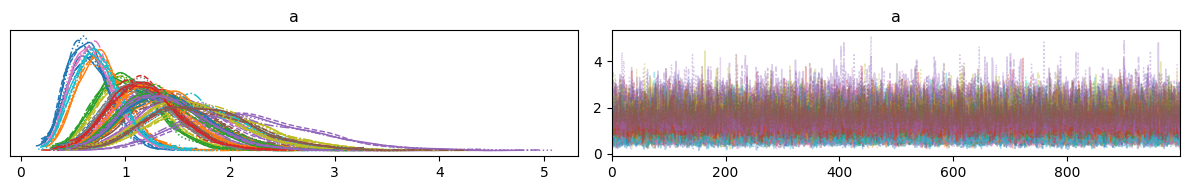

In [62]:
# df_scored를 df로 수정
df_as = df[AS_cols].copy()
fit_as, idata_as = fit_grm(df_as, K=5, scale_name="AS", seed=124)

print(az.summary(idata_as, var_names=["a"]).loc[:, ["mean","sd","r_hat"]].head())
az.plot_trace(idata_as, var_names=["a"])
plt.tight_layout()
plt.show()

01:27:59 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   5%|▌         | 100/2000 [00:04<01:27, 21.70it/s, (Warmup)]



chain 1:  15%|█▌        | 300/2000 [00:12<01:07, 25.00it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:15<00:57, 27.73it/s, (Warmup)]




chain 1:  25%|██▌       | 500/2000 [00:21<01:07, 22.38it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:25<00:59, 23.49it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:29<00:54, 23.96it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:32<00:46, 25.79it/s, (Warmup)]



chain 1:  45%|████▌     | 900/2000 [00:36<00:41, 26.34it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [00:39<00:37, 26.59it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:45<00:39, 22.98it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:50<00:35, 22.54it/s, (Sampling)]



chain 1:  65%|██████▌   | 1300/2000 [00:54<00:31, 22.45it/s, (Sampling)]



01:29:24 - cmdstanpy - INFO - CmdStan done processing.
01:29:24 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -19.9878, but should be greater than the previous element, -19.9878 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -17.8649, but should be greater than the previous element, -17.8649 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -2148.48, but should be greater than the previous element, -2148.48 (in 'grm_unidim.stan', line 24, column 6 to column 56)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -32.6297, but should be greater than the previous element, -32.6297 (in 'grm_unidim.stan', line 24, column 6 to column 56)
Exception: ordered_


       mean     sd  r_hat
a[0]  1.568  0.545    1.0
a[1]  1.184  0.435    1.0
a[2]  1.087  0.374    1.0
a[3]  0.856  0.307    1.0
a[4]  0.717  0.253    1.0


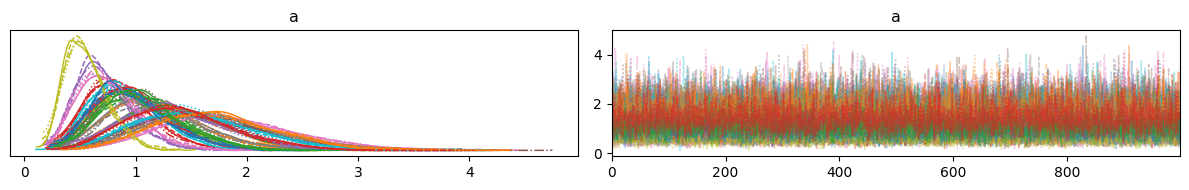

In [63]:
# df_scored를 df로 수정
df_is = df[IS_cols].copy()
fit_is, idata_is = fit_grm(df_is, K=5, scale_name="IS", seed=125)

print(az.summary(idata_is, var_names=["a"]).loc[:, ["mean","sd","r_hat"]].head())
az.plot_trace(idata_is, var_names=["a"])
plt.tight_layout()
plt.show()

In [64]:
def eap_theta(idata):
    th = idata.posterior["theta"].values  # (chain, draw, N)
    th_mean = th.mean(axis=(0,1))
    th_lo, th_hi = np.quantile(th.reshape(-1, th.shape[-1]), [0.05, 0.95], axis=0)
    return th_mean, th_lo, th_hi

theta_se, _, _ = eap_theta(idata_se)
theta_as, _, _ = eap_theta(idata_as)
theta_is, _, _ = eap_theta(idata_is)

latent_df = pd.DataFrame({
    "theta_SE": theta_se,
    "theta_IS": theta_is,
    "theta_AS": theta_as
})

latent_df.corr()

,theta_SE,theta_IS,theta_AS
theta_SE,1.000000,0.338886,-0.482553
theta_IS,0.338886,1.000000,-0.519257
theta_AS,-0.482553,-0.519257,1.000000


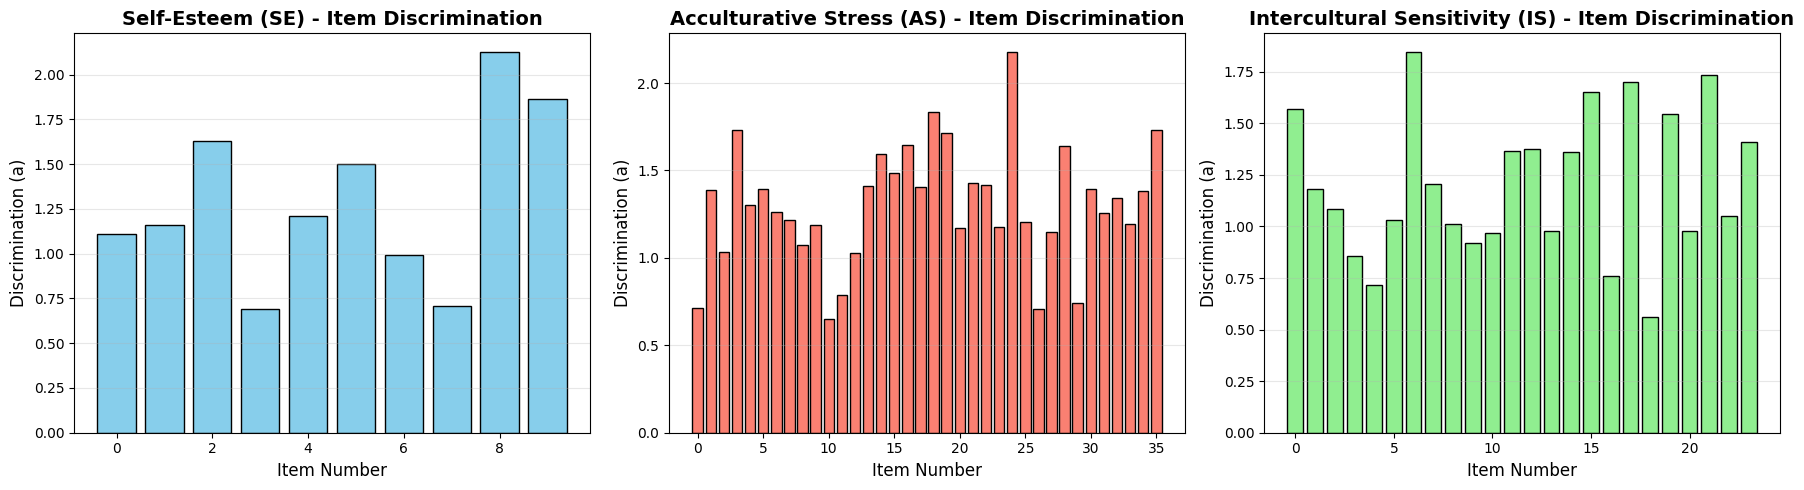

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SE
alpha_se = fit_se.stan_variable('a').mean(axis=0) # 'alpha'를 'a'로 수정
axes[0].bar(range(len(alpha_se)), alpha_se, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Item Number', fontsize=12)
axes[0].set_ylabel('Discrimination (a)', fontsize=12)
axes[0].set_title('Self-Esteem (SE) - Item Discrimination', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# AS
alpha_as = fit_as.stan_variable('a').mean(axis=0) # 'alpha'를 'a'로 수정
axes[1].bar(range(len(alpha_as)), alpha_as, color='salmon', edgecolor='black')
axes[1].set_xlabel('Item Number', fontsize=12)
axes[1].set_ylabel('Discrimination (a)', fontsize=12)
axes[1].set_title('Acculturative Stress (AS) - Item Discrimination', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# IS
alpha_is = fit_is.stan_variable('a').mean(axis=0) # 'alpha'를 'a'로 수정
axes[2].bar(range(len(alpha_is)), alpha_is, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Item Number', fontsize=12)
axes[2].set_ylabel('Discrimination (a)', fontsize=12)
axes[2].set_title('Intercultural Sensitivity (IS) - Item Discrimination', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('discrimination_parameters.png', dpi=300, bbox_inches='tight')
plt.show()